In [41]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(7)

# ----------------------------
# Data
# ----------------------------
def f(x):
    return x*torch.sin(2 * x)

sigma = 0.1
n_train = 256
n_test = 1000

x_train = torch.linspace(-11, 11.0, n_train).unsqueeze(1)
x_test  = torch.linspace(-9, 3, n_test).unsqueeze(1)

y_train_true = f(x_train)
y_test_true  = f(x_test)

y_train = y_train_true + sigma * torch.randn_like(y_train_true)
y_test  = y_test_true  + sigma * torch.randn_like(y_test_true)

# normalize input only (helps the nets)
def scale_x(x):
    return x / 11.0

# ----------------------------
# Models
# ----------------------------
class PolyModel(nn.Module):
    def __init__(self, degree=7):
        super().__init__()
        self.degree = degree
        self.linear = nn.Linear(degree + 1, 1, bias=False)

    def features(self, x):
        z = scale_x(x)
        return torch.cat([z ** k for k in range(self.degree + 1)], dim=1)

    def forward(self, x):
        return self.linear(self.features(x))


class MLP(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, x):
        return self.net(scale_x(x))


class ResBlock(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNet(nn.Module):
    def __init__(self, width=64, depth=3):
        super().__init__()
        self.in_proj = nn.Linear(1, width)
        self.blocks = nn.ModuleList([ResBlock(width) for _ in range(depth)])
        self.out_proj = nn.Linear(width, 1)

    def forward(self, x):
        h = torch.tanh(self.in_proj(scale_x(x)))
        for block in self.blocks:
            h = torch.tanh(block(h))
        return self.out_proj(h)


# ----------------------------
# Training
# ----------------------------
def train_model(model, x_train, y_train, x_test, y_test, epochs=2000, lr=1e-2):
    loss_fn = nn.MSELoss()
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.1)

    train_losses = []
    test_losses = []

    for _ in range(epochs):
        opt.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        opt.step()

        with torch.no_grad():
            train_losses.append(loss.item())
            test_losses.append(loss_fn(model(x_test), y_test).item())

    return train_losses, test_losses



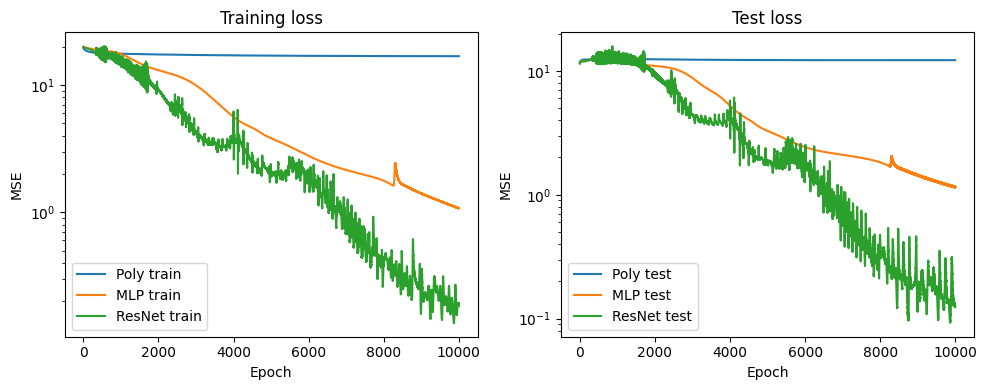

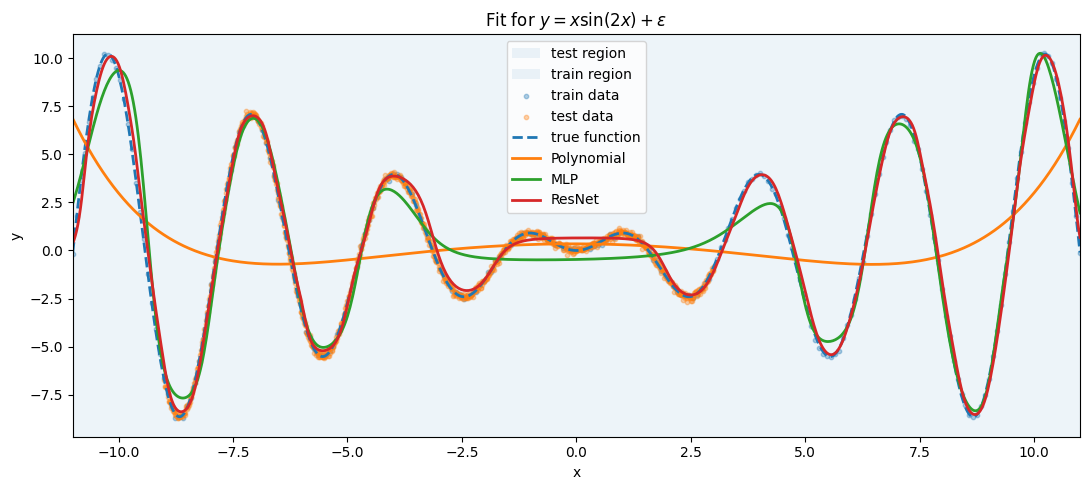

: 

In [ ]:
poly = PolyModel(degree=7)
mlp = MLP(width=64)
resnet = ResNet(width=32, depth=3)

hist_poly = train_model(poly, x_train, y_train, x_test, y_test, epochs=10000, lr=1e-2)
hist_mlp = train_model(mlp, x_train, y_train, x_test, y_test, epochs=10000, lr=1e-2)
hist_res = train_model(resnet, x_train, y_train, x_test, y_test, epochs=10000, lr=1e-2)

# ----------------------------
# Predictions for plotting
# ----------------------------
x_plot = torch.linspace(-11.0, 11.0, 800).unsqueeze(1)
y_plot_true = f(x_plot)

with torch.no_grad():
    y_poly = poly(x_plot)
    y_mlp = mlp(x_plot)
    y_res = resnet(x_plot)

# ----------------------------
# Plot 1: loss curves
# ----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_poly[0], label="Poly train")
plt.plot(hist_mlp[0], label="MLP train")
plt.plot(hist_res[0], label="ResNet train")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_poly[1], label="Poly test")
plt.plot(hist_mlp[1], label="MLP test")
plt.plot(hist_res[1], label="ResNet test")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Test loss")
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: fit over full domain
# ----------------------------
plt.figure(figsize=(11, 5))

plt.axvspan(-11, 0, alpha=0.08, label="test region")
plt.axvspan(0, 11, alpha=0.08, label="train region")

plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.35, label="train data")
plt.scatter(x_test.numpy(), y_test.numpy(), s=10, alpha=0.35, label="test data")

plt.plot(x_plot.numpy(), y_plot_true.numpy(), "--", linewidth=2, label="true function")
plt.plot(x_plot.numpy(), y_poly.numpy(), linewidth=2, label="Polynomial")
plt.plot(x_plot.numpy(), y_mlp.numpy(), linewidth=2, label="MLP")
plt.plot(x_plot.numpy(), y_res.numpy(), linewidth=2, label="ResNet")

plt.xlim(-11, 11)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Fit for $y = x\sin(2x) + \varepsilon$")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
print(poly)
print(mlp)
print(resnet)

PolyModel(
  (linear): Linear(in_features=8, out_features=1, bias=False)
)
MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
ResNet(
  (in_proj): Linear(in_features=1, out_features=16, bias=True)
  (blocks): ModuleList(
    (0-2): 3 x ResBlock(
      (block): Sequential(
        (0): Linear(in_features=16, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
    )
  )
  (out_proj): Linear(in_features=16, out_features=1, bias=True)
)


In [9]:
def summarize(model):
    print(model)
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {n_params}")
    print(f"Trainable params: {n_trainable}")
    print("-" * 50)

summarize(poly)
summarize(mlp)
summarize(resnet)

PolyModel(
  (linear): Linear(in_features=8, out_features=1, bias=False)
)
Total params: 8
Trainable params: 8
--------------------------------------------------
MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total params: 4353
Trainable params: 4353
--------------------------------------------------
ResNet(
  (in_proj): Linear(in_features=1, out_features=16, bias=True)
  (blocks): ModuleList(
    (0-2): 3 x ResBlock(
      (block): Sequential(
        (0): Linear(in_features=16, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
    )
  )
  (out_proj): Linear(in_features=16, out_features=1, bias=True)
)
Total params: 1681
Trainable params: 1681
--------------------------------------------------
